# EEG-Based Age Classification — Dortmund Vital Study Resting-State EEG
## Notebook 04: Gradient Boosting Classifier

**Dataset:** DS005385 — Resting-state EEG data before and after cognitive activity across the adult lifespan
**Depends on:** `03_spectral_feature_extraction.ipynb` (produces `spectral_features.csv`)

### Purpose
This notebook trains and evaluates a gradient boosting classifier that predicts whether a person belongs to the young (20-34 years) or old (52-70 years) group from their resting-state EEG spectral features alone. The evaluation is designed to give an unbiased estimate of performance on unseen individuals, to test whether that performance is statistically above chance, and to identify which frequency bands drive the predictions.

### Analysis overview
1. Load the feature matrix (405 subjects, 321 spectral features).
2. Define a nested cross-validation scheme that separates model tuning from model evaluation.
3. Compare gradient boosting against a chance baseline and a regularized logistic regression.
4. Examine out-of-fold predictions with ROC curves and a confusion matrix.
5. Test statistical significance with a label-permutation test.
6. Measure the importance of each frequency band with grouped permutation importance.
7. Run feature-set ablations, including a check for possible muscle contamination in the gamma band.
8. Train and save the final model.

## Execution Environment: Local

Unlike Notebooks 00-03, this notebook runs on a **local** Python environment (the project's `.venv`), not on Google Colab. Its only input is the small feature matrix produced by Notebook 03 (`data/spectral_features.csv`), so it needs no network access, no raw EEG data and no EEG-specific libraries, only scikit-learn, pandas, NumPy and matplotlib. This keeps the modeling stage fast and fully reproducible: anyone who clones this repository can rerun it in a few minutes.

Results tables are written to `results/`, figures to `figures/`, and the trained model to `models/`.

In [1]:
"""
Imports, reproducibility settings, and project paths.

Paths are resolved relative to the project root, so the notebook works
whether it is launched from the project folder or from notebooks/.
"""

import json
import sys
import time
from collections import Counter
from pathlib import Path

%matplotlib inline
import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             balanced_accuracy_score, roc_auc_score, roc_curve)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     cross_val_score, permutation_test_score)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"
for directory in (FIGURES_DIR, RESULTS_DIR, MODELS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Python       : {sys.version.split()[0]}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"pandas       : {pd.__version__}")
print(f"numpy        : {np.__version__}")
print(f"matplotlib   : {matplotlib.__version__}")

Project root : /Users/AleeshaHayat/Documents/02_EEG_Age_Classification_DortmundVitAL
Python       : 3.12.0
scikit-learn : 1.9.1
pandas       : 3.0.6
numpy        : 2.5.3
matplotlib   : 3.11.2


## Step 1 — Load the Feature Matrix

The feature matrix from Notebook 03 contains one row per subject: the subject ID, the age-group label, and 321 spectral features (relative power in 5 bands at 64 electrodes, plus the individual alpha peak frequency). The label is encoded as `old = 1` and `young = 0`. Subject age is not part of the file, so the model cannot access the answer directly.

In [2]:
"""
Load the feature matrix, run integrity checks, and build the feature
array X and label vector y.
"""

features_path = DATA_DIR / "spectral_features.csv"
if not features_path.exists():
    raise FileNotFoundError(
        f"{features_path} not found. Download spectral_features.csv from Notebook 03 "
        "and place it in the project's data/ folder."
    )

features_df = pd.read_csv(features_path, dtype={"subject": str})

FEATURE_COLS = [c for c in features_df.columns if c not in ("subject", "age_group")]
LABELS = {"young": 0, "old": 1}

assert "age" not in features_df.columns, "Age must not be present in the feature matrix."
assert features_df["subject"].is_unique, "Each subject must appear exactly once."
assert features_df[FEATURE_COLS].notna().all().all(), "Feature matrix contains missing values."

X = features_df[FEATURE_COLS].to_numpy()
y = features_df["age_group"].map(LABELS).to_numpy()

print(f"Subjects : {X.shape[0]}")
print(f"Features : {X.shape[1]}")
print("\nClass balance:")
print(features_df["age_group"].value_counts())
print(f"\nMajority-class rate (accuracy of always guessing 'old'): {y.mean():.3f}")

Subjects : 405
Features : 321

Class balance:
age_group
old      209
young    196
Name: count, dtype: int64

Majority-class rate (accuracy of always guessing 'old'): 0.516


## Step 2 — Define the Evaluation Scheme: Nested Cross-Validation

A model's performance must be measured on people it has never seen, and the choice of model settings (hyperparameters) must not be informed by those same people. **Nested cross-validation** satisfies both requirements:

- **Outer loop (5 folds):** the subjects are split into 5 stratified groups. Each group serves once as the held-out test set while the model is developed on the other four. The five test scores are averaged to estimate performance on new individuals.
- **Inner loop (3 folds):** within each outer training set only, a further cross-validation selects the best hyperparameters. The outer test fold is never involved in this choice.

Because each row is one whole subject, a person can never appear in both the training and the test data. Any preprocessing that learns from data (here, feature standardization for logistic regression) is fitted inside the training folds only.

Three metrics are reported: **accuracy** (share of correct predictions), **balanced accuracy** (mean of the per-group accuracies, unaffected by the slight class imbalance) and **ROC AUC** (the probability that a randomly chosen old subject receives a higher "old" score than a randomly chosen young subject; 0.5 is chance, 1.0 is perfect).

In [3]:
"""
Define the cross-validation splitters and a scoring helper used for
every model.
"""

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

METRICS = ["accuracy", "balanced_accuracy", "roc_auc"]


def score_predictions(y_true, proba, threshold=0.5):
    """Compute accuracy, balanced accuracy and ROC AUC from predicted probabilities."""
    predicted = (proba >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, predicted),
        "balanced_accuracy": balanced_accuracy_score(y_true, predicted),
        "roc_auc": roc_auc_score(y_true, proba),
    }


for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), start=1):
    print(f"Outer fold {fold}: train {len(train_idx)} subjects, test {len(test_idx)} subjects "
          f"(test share old = {y[test_idx].mean():.2f})")

Outer fold 1: train 324 subjects, test 81 subjects (test share old = 0.52)
Outer fold 2: train 324 subjects, test 81 subjects (test share old = 0.52)
Outer fold 3: train 324 subjects, test 81 subjects (test share old = 0.52)
Outer fold 4: train 324 subjects, test 81 subjects (test share old = 0.52)
Outer fold 5: train 324 subjects, test 81 subjects (test share old = 0.51)


## Step 3 — Define the Models

Three models are compared under the same cross-validation scheme:

- **Chance baseline:** always predicts the larger group. Any useful model must clearly beat it.
- **Logistic regression:** a regularized linear model on standardized features. It shows how much can be achieved by a weighted sum of the features, and therefore whether a more flexible model adds value. The regularization strength `C` is tuned in the inner loop.
- **Gradient boosting:** an ensemble of shallow decision trees built sequentially, each tree correcting the errors of those before it. It can capture non-linear relationships and interactions between features, and is insensitive to feature scaling. The number of trees, the learning rate (how strongly each tree corrects the previous ones) and the tree depth are tuned in the inner loop; each tree is trained on a random 80% of the training subjects (`subsample = 0.8`), which reduces overfitting.

The hyperparameter grids are deliberately small: with about 320 training subjects per fold, a large search would risk fitting noise in the inner validation folds.

In [4]:
"""
Model definitions and their hyperparameter grids (None = no tuning).
"""

GB_PARAM_GRID = {
    "n_estimators": [100, 300],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3],
    "subsample": [0.8],
}

MODELS = {
    "Chance baseline": (
        DummyClassifier(strategy="most_frequent"),
        None,
    ),
    "Logistic regression": (
        make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
        {"logisticregression__C": [0.001, 0.01, 0.1, 1.0]},
    ),
    "Gradient boosting": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        GB_PARAM_GRID,
    ),
}

for name, (_, grid) in MODELS.items():
    n_configs = int(np.prod([len(v) for v in grid.values()])) if grid else 1
    print(f"{name:20s}: {n_configs} hyperparameter configuration(s)")

Chance baseline     : 1 hyperparameter configuration(s)
Logistic regression : 4 hyperparameter configuration(s)
Gradient boosting   : 8 hyperparameter configuration(s)


## Step 4 — Run Nested Cross-Validation

Each model is evaluated with the nested scheme from Step 2. For every outer fold, the tuned model, its selected hyperparameters, its test-fold scores and its predicted probabilities for the held-out subjects are stored. Collecting these **out-of-fold** probabilities gives every subject exactly one prediction made by a model that never saw them during training, which is used for the ROC curves and confusion matrix in Step 5. Gradient boosting takes the longest to run (a few minutes).

In [5]:
"""
Nested cross-validation for every model, collecting fold scores,
out-of-fold probabilities, selected hyperparameters and fitted models.
"""

def run_nested_cv(estimator, param_grid, X, y):
    """Evaluate one model with nested cross-validation."""
    fold_rows, best_params, fitted_models, test_indices = [], [], [], []
    oof_proba = np.zeros(len(y))

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), start=1):
        if param_grid:
            search = GridSearchCV(clone(estimator), param_grid, cv=inner_cv,
                                  scoring="roc_auc", n_jobs=-1)
            search.fit(X[train_idx], y[train_idx])
            model = search.best_estimator_
            best_params.append(search.best_params_)
        else:
            model = clone(estimator).fit(X[train_idx], y[train_idx])

        proba = model.predict_proba(X[test_idx])[:, 1]
        oof_proba[test_idx] = proba
        fold_rows.append({"fold": fold, **score_predictions(y[test_idx], proba)})
        fitted_models.append(model)
        test_indices.append(test_idx)

    return {
        "fold_scores": pd.DataFrame(fold_rows),
        "oof_proba": oof_proba,
        "best_params": best_params,
        "models": fitted_models,
        "test_indices": test_indices,
    }


results = {}
for name, (estimator, grid) in MODELS.items():
    start = time.perf_counter()
    results[name] = run_nested_cv(estimator, grid, X, y)
    print(f"{name:20s} finished in {time.perf_counter() - start:6.1f} s")

Chance baseline      finished in    0.0 s
Logistic regression  finished in    2.2 s
Gradient boosting    finished in   26.1 s


In [6]:
"""
Summarize nested cross-validation performance (mean ± standard
deviation across the 5 outer folds) and list the hyperparameters
selected in each fold.
"""

comparison = pd.concat(
    {name: r["fold_scores"][METRICS].agg(["mean", "std"]).T for name, r in results.items()}
)
comparison.index.names = ["model", "metric"]

display_table = pd.DataFrame({
    name: {m: f"{r['fold_scores'][m].mean():.3f} ± {r['fold_scores'][m].std():.3f}" for m in METRICS}
    for name, r in results.items()
}).T
print("Nested cross-validation performance (mean ± SD across 5 outer folds):")
print(display_table.to_string())

for name in ("Logistic regression", "Gradient boosting"):
    print(f"\nHyperparameters selected per outer fold, {name}:")
    for fold, params in enumerate(results[name]["best_params"], start=1):
        print(f"  fold {fold}: {params}")

comparison.to_csv(RESULTS_DIR / "model_comparison.csv")

Nested cross-validation performance (mean ± SD across 5 outer folds):
                          accuracy balanced_accuracy        roc_auc
Chance baseline      0.516 ± 0.006     0.500 ± 0.000  0.500 ± 0.000
Logistic regression  0.830 ± 0.029     0.829 ± 0.029  0.904 ± 0.027
Gradient boosting    0.795 ± 0.027     0.795 ± 0.027  0.895 ± 0.017

Hyperparameters selected per outer fold, Logistic regression:
  fold 1: {'logisticregression__C': 0.1}
  fold 2: {'logisticregression__C': 0.1}
  fold 3: {'logisticregression__C': 0.1}
  fold 4: {'logisticregression__C': 0.01}
  fold 5: {'logisticregression__C': 0.1}

Hyperparameters selected per outer fold, Gradient boosting:
  fold 1: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
  fold 2: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 300, 'subsample': 0.8}
  fold 3: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 300, 'subsample': 0.8}
  fold 4: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators'

## Step 5 — Examine Out-of-Fold Predictions

The **ROC curve** shows, across every possible decision threshold, the trade-off between correctly identifying older adults (true-positive rate) and wrongly labeling younger adults as old (false-positive rate). The curve is built from the pooled out-of-fold probabilities, so its area can differ slightly from the mean of the per-fold AUCs above. The **confusion matrix** shows the gradient boosting model's predictions at the default 0.5 threshold, revealing whether errors are balanced between the groups or concentrated in one.

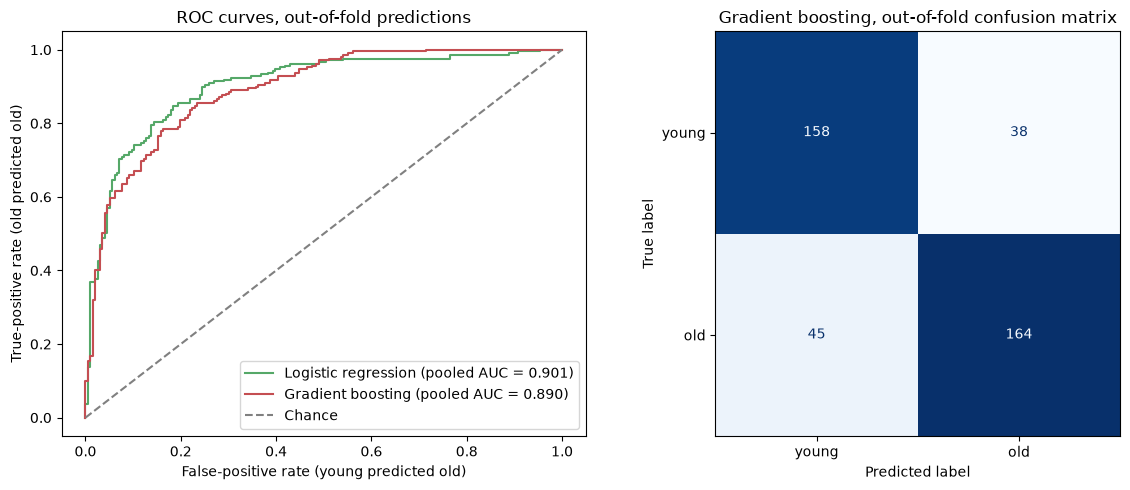

In [7]:
"""
ROC curves (logistic regression and gradient boosting) and the gradient
boosting confusion matrix, from out-of-fold predictions.
"""

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name, color in (("Logistic regression", "#55A868"), ("Gradient boosting", "#C44E52")):
    proba = results[name]["oof_proba"]
    fpr, tpr, _ = roc_curve(y, proba)
    axes[0].plot(fpr, tpr, color=color, label=f"{name} (pooled AUC = {roc_auc_score(y, proba):.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
axes[0].set_xlabel("False-positive rate (young predicted old)")
axes[0].set_ylabel("True-positive rate (old predicted old)")
axes[0].set_title("ROC curves, out-of-fold predictions")
axes[0].legend(loc="lower right")

gb_predicted = (results["Gradient boosting"]["oof_proba"] >= 0.5).astype(int)
ConfusionMatrixDisplay.from_predictions(
    y, gb_predicted, display_labels=["young", "old"], cmap="Blues", colorbar=False, ax=axes[1]
)
axes[1].set_title("Gradient boosting, out-of-fold confusion matrix")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "04_roc_and_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 6 — Test Statistical Significance with a Permutation Test

A permutation test asks how likely the observed performance would be if EEG spectra carried no information about age group. The age-group labels are randomly shuffled, breaking any genuine link between features and labels, and the full cross-validation is repeated; this is done 100 times to build a distribution of chance-level scores. The p-value is the proportion of shuffled runs that score at least as well as the real labels (the smallest possible value with 100 permutations is 1/101 ≈ 0.01).

To keep the run time practical, gradient boosting is used here with fixed hyperparameters: the configuration selected most often across the outer folds in Step 4.

Fixed gradient boosting hyperparameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 300, 'subsample': 0.8}
Finished in 132.3 s

Cross-validated ROC AUC with true labels : 0.902
ROC AUC with shuffled labels (mean ± SD) : 0.495 ± 0.038
Permutation p-value                      : 0.0099


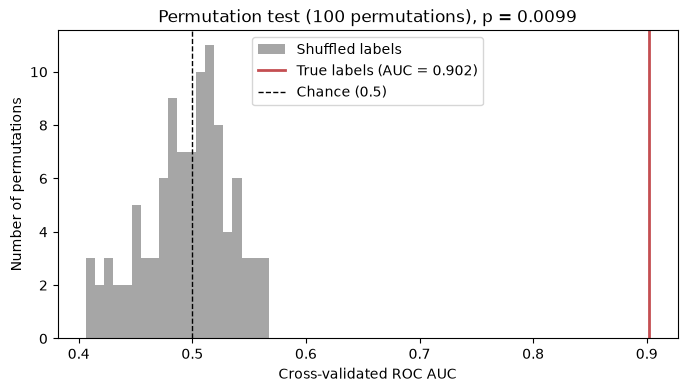

In [8]:
"""
Label-permutation test for gradient boosting with fixed hyperparameters.
"""

N_PERMUTATIONS = 100

param_counts = Counter(tuple(sorted(p.items())) for p in results["Gradient boosting"]["best_params"])
FIXED_GB_PARAMS = dict(param_counts.most_common(1)[0][0])
print(f"Fixed gradient boosting hyperparameters: {FIXED_GB_PARAMS}")

start = time.perf_counter()
true_auc, permuted_aucs, p_value = permutation_test_score(
    GradientBoostingClassifier(random_state=RANDOM_STATE, **FIXED_GB_PARAMS),
    X, y, cv=outer_cv, scoring="roc_auc",
    n_permutations=N_PERMUTATIONS, n_jobs=-1, random_state=RANDOM_STATE,
)
print(f"Finished in {time.perf_counter() - start:.1f} s")
print(f"\nCross-validated ROC AUC with true labels : {true_auc:.3f}")
print(f"ROC AUC with shuffled labels (mean ± SD) : {permuted_aucs.mean():.3f} ± {permuted_aucs.std():.3f}")
print(f"Permutation p-value                      : {p_value:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(permuted_aucs, bins=20, color="grey", alpha=0.7, label="Shuffled labels")
ax.axvline(true_auc, color="#C44E52", linewidth=2, label=f"True labels (AUC = {true_auc:.3f})")
ax.axvline(0.5, color="black", linestyle="--", linewidth=1, label="Chance (0.5)")
ax.set_xlabel("Cross-validated ROC AUC")
ax.set_ylabel("Number of permutations")
ax.set_title(f"Permutation test ({N_PERMUTATIONS} permutations), p = {p_value:.4f}")
ax.legend()
fig.savefig(FIGURES_DIR / "04_permutation_test.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 7 — Identify Which Frequency Bands Drive the Predictions

**Permutation importance** measures how much a model relies on a feature: the feature's values are shuffled across subjects in the held-out test data, and the resulting drop in ROC AUC is recorded. A large drop means the model depends on that information.

Neighbouring electrodes carry highly correlated information, so shuffling one channel at a time would understate importance (the model can recover the same information from the channel next to it). Features are therefore shuffled **as a group**: all 64 channels of a band together, and the alpha peak frequency on its own. This is done on each outer test fold with that fold's tuned model, repeated 20 times, and averaged across folds.

delta            : 64 features
theta            : 64 features
alpha            : 64 features
beta             : 64 features
gamma            : 64 features
alpha peak (IAF) : 1 features

Drop in ROC AUC when each feature group is shuffled (mean ± SD across folds):
                    mean     std
feature_group                   
alpha             0.0038  0.0089
alpha peak (IAF)  0.0257  0.0108
delta             0.0282  0.0096
gamma             0.0354  0.0226
theta             0.0385  0.0106
beta              0.1790  0.0320


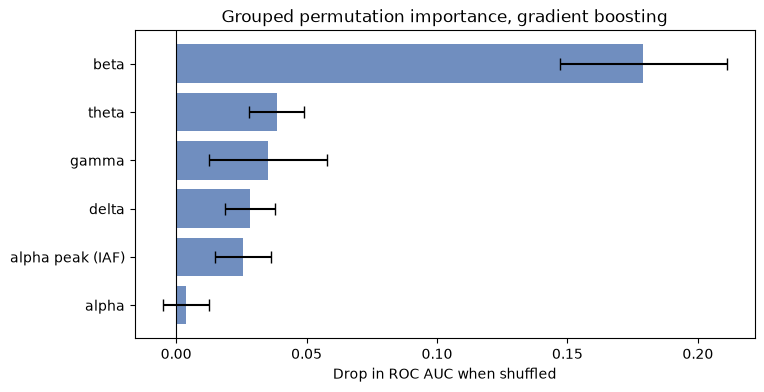

In [9]:
"""
Grouped permutation importance per frequency band, computed on the
held-out outer folds with the nested-CV gradient boosting models.
"""

BANDS = ["delta", "theta", "alpha", "beta", "gamma"]
FEATURE_GROUPS = {band: [i for i, c in enumerate(FEATURE_COLS) if c.endswith(f"_{band}")]
                  for band in BANDS}
FEATURE_GROUPS["alpha peak (IAF)"] = [FEATURE_COLS.index("iaf")]
for group, idx in FEATURE_GROUPS.items():
    print(f"{group:17s}: {len(idx)} features")

N_REPEATS = 20
rng = np.random.default_rng(RANDOM_STATE)
rows = []

gb_results = results["Gradient boosting"]
for fold, (model, test_idx) in enumerate(zip(gb_results["models"], gb_results["test_indices"]), start=1):
    X_test, y_test = X[test_idx], y[test_idx]
    baseline_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    for group, columns in FEATURE_GROUPS.items():
        drops = []
        for _ in range(N_REPEATS):
            X_shuffled = X_test.copy()
            order = rng.permutation(len(X_test))
            X_shuffled[:, columns] = X_test[order][:, columns]
            drops.append(baseline_auc - roc_auc_score(y_test, model.predict_proba(X_shuffled)[:, 1]))
        rows.append({"fold": fold, "feature_group": group, "auc_drop": np.mean(drops)})

band_importance = (pd.DataFrame(rows).groupby("feature_group")["auc_drop"]
                   .agg(["mean", "std"]).sort_values("mean"))
print("\nDrop in ROC AUC when each feature group is shuffled (mean ± SD across folds):")
print(band_importance.round(4).to_string())
band_importance.to_csv(RESULTS_DIR / "band_importance.csv")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(band_importance.index, band_importance["mean"], xerr=band_importance["std"],
        color="#4C72B0", alpha=0.8, capsize=4)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Drop in ROC AUC when shuffled")
ax.set_title("Grouped permutation importance, gradient boosting")
fig.savefig(FIGURES_DIR / "04_band_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 8 — Feature-Set Ablations

The model is retrained on restricted feature sets to test specific questions:

- **Without gamma:** gamma-band (30-45 Hz) power at scalp electrodes can be contaminated by muscle activity, and Notebook 03 showed the old-minus-young gamma difference concentrated at lateral frontotemporal sites, where jaw and temple muscles are located. If performance holds without gamma, the classifier does not depend on this possibly non-neural signal.
- **Alpha + alpha peak frequency only:** how much is achieved with the rhythm most strongly linked to aging.
- **Beta only:** the band with the largest increase in older adults.
- **Alpha peak frequency only:** a single, physiologically interpretable number per subject.

Each ablation uses the same outer folds and the fixed hyperparameters from Step 6. Because those hyperparameters were chosen using the full dataset, the absolute values here are slightly optimistic; the comparison *between* feature sets is what matters.

       feature_set  n_features  roc_auc_mean  roc_auc_std
      All features         321         0.902        0.018
     Without gamma         257         0.895        0.020
Alpha + alpha peak          65         0.783        0.053
         Beta only          64         0.812        0.025
   Alpha peak only           1         0.590        0.085


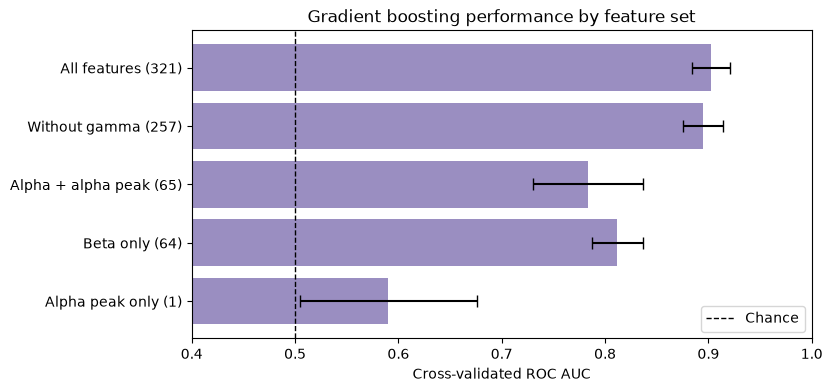

In [10]:
"""
Cross-validated ROC AUC of gradient boosting on restricted feature sets.
"""

all_idx = list(range(len(FEATURE_COLS)))
gamma_idx = set(FEATURE_GROUPS["gamma"])
ABLATION_SETS = {
    "All features": all_idx,
    "Without gamma": [i for i in all_idx if i not in gamma_idx],
    "Alpha + alpha peak": FEATURE_GROUPS["alpha"] + FEATURE_GROUPS["alpha peak (IAF)"],
    "Beta only": FEATURE_GROUPS["beta"],
    "Alpha peak only": FEATURE_GROUPS["alpha peak (IAF)"],
}

ablation_rows = []
for name, columns in ABLATION_SETS.items():
    scores = cross_val_score(
        GradientBoostingClassifier(random_state=RANDOM_STATE, **FIXED_GB_PARAMS),
        X[:, columns], y, cv=outer_cv, scoring="roc_auc", n_jobs=-1,
    )
    ablation_rows.append({"feature_set": name, "n_features": len(columns),
                          "roc_auc_mean": scores.mean(), "roc_auc_std": scores.std()})

ablation = pd.DataFrame(ablation_rows)
print(ablation.round(3).to_string(index=False))
ablation.to_csv(RESULTS_DIR / "ablation.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))
labels = [f"{r.feature_set} ({r.n_features})" for r in ablation.itertuples()]
ax.barh(labels[::-1], ablation["roc_auc_mean"][::-1], xerr=ablation["roc_auc_std"][::-1],
        color="#8172B2", alpha=0.8, capsize=4)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1, label="Chance")
ax.set_xlim(0.4, 1.0)
ax.set_xlabel("Cross-validated ROC AUC")
ax.set_title("Gradient boosting performance by feature set")
ax.legend(loc="lower right")
fig.savefig(FIGURES_DIR / "04_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 9 — Train and Save the Final Model

The cross-validation above estimates how well the *procedure* generalizes. The final model is produced by applying that same procedure (hyperparameter search with 5-fold cross-validation, then refitting on the selected configuration) to all 405 subjects. It is saved together with the exact feature order and label encoding it expects, and a JSON summary records the main results and software versions for reproducibility.

In [11]:
"""
Fit the final gradient boosting model on all subjects, save it with its
feature list and label encoding, and write a JSON summary of results.
"""

final_search = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE), GB_PARAM_GRID,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="roc_auc", n_jobs=-1,
)
final_search.fit(X, y)
print(f"Final model hyperparameters: {final_search.best_params_}")

model_path = MODELS_DIR / "gradient_boosting_age_classifier.joblib"
joblib.dump({"model": final_search.best_estimator_,
             "feature_columns": FEATURE_COLS,
             "label_mapping": LABELS}, model_path)
print(f"Saved model to {model_path}")

gb_scores = results["Gradient boosting"]["fold_scores"]
summary = {
    "dataset": "OpenNeuro ds005385 (Dortmund Vital Study), session 1, eyes-closed, pre-task",
    "n_subjects": int(len(y)),
    "n_features": int(X.shape[1]),
    "class_counts": features_df["age_group"].value_counts().to_dict(),
    "evaluation": "nested cross-validation (5 outer folds, 3 inner folds)",
    "gradient_boosting_nested_cv": {m: {"mean": float(gb_scores[m].mean()), "std": float(gb_scores[m].std())}
                                    for m in METRICS},
    "permutation_test": {"n_permutations": N_PERMUTATIONS, "true_roc_auc": float(true_auc),
                         "p_value": float(p_value), "fixed_hyperparameters": FIXED_GB_PARAMS},
    "final_model_hyperparameters": final_search.best_params_,
    "software": {"python": sys.version.split()[0], "scikit-learn": sklearn.__version__,
                 "pandas": pd.__version__, "numpy": np.__version__},
}
with open(RESULTS_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(f"Saved results summary to {RESULTS_DIR / 'summary.json'}")

Final model hyperparameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 300, 'subsample': 0.8}
Saved model to /Users/AleeshaHayat/Documents/02_EEG_Age_Classification_DortmundVitAL/models/gradient_boosting_age_classifier.joblib
Saved results summary to /Users/AleeshaHayat/Documents/02_EEG_Age_Classification_DortmundVitAL/results/summary.json


## Summary

Using 321 resting-state EEG spectral features from 405 adults, a gradient boosting classifier distinguished young (20-34 years) from older (52-70 years) adults with a nested cross-validated ROC AUC of **0.895 ± 0.017**, accuracy of **0.795 ± 0.027** and balanced accuracy of **0.795 ± 0.027**, against a chance level of 0.500 (AUC) and 0.516 (accuracy). Errors were balanced between groups: out of fold, 158 of 196 younger adults (80.6%) and 164 of 209 older adults (78.5%) were classified correctly. A label-permutation test confirmed performance far above chance: ROC AUC 0.902 with the true labels versus 0.495 ± 0.038 with shuffled labels (p = 0.0099, the smallest value attainable with 100 permutations).

A regularized logistic regression performed comparably (ROC AUC 0.904 ± 0.027, accuracy 0.830 ± 0.029). The difference lies within one standard deviation across folds, indicating that the age-related spectral differences in this cohort are captured largely by a linear combination of features, and that the additional flexibility of gradient boosting brings no measurable benefit here.

Beta-band power was by far the most important feature group (ROC AUC drop of 0.179 when shuffled), followed by theta (0.039), gamma (0.035), delta (0.028) and the individual alpha peak frequency (0.026). Alpha power showed the smallest drop (0.004) despite a large group difference in Notebook 03: because relative band powers sum to one, alpha can be reconstructed from the other four bands, so shuffling it alone removes little information. On their own, alpha power and the alpha peak frequency still reached a ROC AUC of 0.783 in the ablation analysis. Removing all gamma features changed performance only marginally (0.902 to 0.895), showing that the classifier does not depend on the frequency range most susceptible to muscle artifact.

The final model (300 trees of depth 2, learning rate 0.1, subsample 0.8), trained on all 405 subjects, is saved in `models/`, with results tables in `results/` and figures in `figures/`.